# Holt-Winters aplicado ao preço de abertura da Microsoft

Alvo: `Open`, preço de abertura da ação MSFT, agregado em média mensal.

A suavização exponencial é uma família de modelos que descreve a série por componentes
observáveis: nível, tendência e sazonalidade. Cada componente é atualizado a cada nova
observação, dando peso maior ao que aconteceu recentemente.

Roteiro do notebook:

| seção | conteúdo |
|---|---|
| 0 | dependências |
| 1 | carga e agregação mensal |
| 2 | definição do período sazonal |
| 3 | separação treino e teste |
| 4 | suavização exponencial simples |
| 5 | Holt-Winters aditivo |
| 6 | Holt-Winters multiplicativo |
| 7 | escolha do modelo por AIC e BIC |
| 8 | previsão e métricas de erro |
| 9 | comparação com SARIMA |
| 10 | resíduos |
| 11 | conclusões |

Uma diferença importante em relação ao notebook de SARIMAX: a suavização exponencial não exige
estacionariedade nem diferenciação. Por isso aqui não há teste ADF nem escolha de `d`.

## 0. Dependências

`pandas` e `numpy` para manipular os dados, `matplotlib` para os gráficos, `statsmodels` para os
modelos de suavização e SARIMA, e `sklearn` para as métricas de erro.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
np.random.seed(42)


Ambiente pronto.


## 1. Carga dos dados e agregação mensal

O arquivo `Microsoft_Stock.csv` traz a cotação diária da MSFT entre abril de 2015 e março de 2021.

O Holt-Winters estima sazonalidade, isto é, um padrão que se repete a cada `m` períodos. Na série
diária da bolsa não existe um ciclo fixo confiável: o pregão tem 5 dias, mas feriados quebram o
ritmo e o efeito do dia da semana sobre o preço é muito fraco.

Agregando para média mensal obtemos um período sazonal natural e bem definido, `m = 12`, uma série
suavizada sem o ruído diário que atrapalharia a estimação de alfa, beta e gama, e 72 observações,
tamanho compatível com o que foi trabalhado em aula.

A agregação usa a média do mês, e não o último dia, porque a média representa o nível típico do
mês inteiro e é menos sensível a um único pregão atípico.

In [2]:
CAMINHO = "Microsoft_Stock.csv"

bruto = pd.read_csv(CAMINHO)
bruto["Date"] = pd.to_datetime(bruto["Date"], format="%m/%d/%Y %H:%M:%S")

# média mensal do preço de abertura; 'MS' = Month Start
serie = bruto.set_index("Date")["Open"].resample("MS").mean()
serie.name = "Open"

print(f"Observações diárias : {len(bruto)}")
print(f"Observações mensais : {len(serie)}")
print(f"Período             : {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}")
print(f"Valores ausentes    : {serie.isna().sum()}")
print(f"Mínimo              : US$ {serie.min():.2f}  |  Máximo: US$ {serie.max():.2f}")
serie.head()

Observações diárias : 1511
Observações mensais : 72
Período             : 2015-04 a 2021-03
Valores ausentes    : 0
Mínimo              : US$ 43.07  |  Máximo: US$ 239.62


Date
2015-04-01   43.0710
2015-05-01   47.5900
2015-06-01   46.1045
2015-07-01   45.4845
2015-08-01   45.5419
Freq: MS, Name: Open, dtype: float64

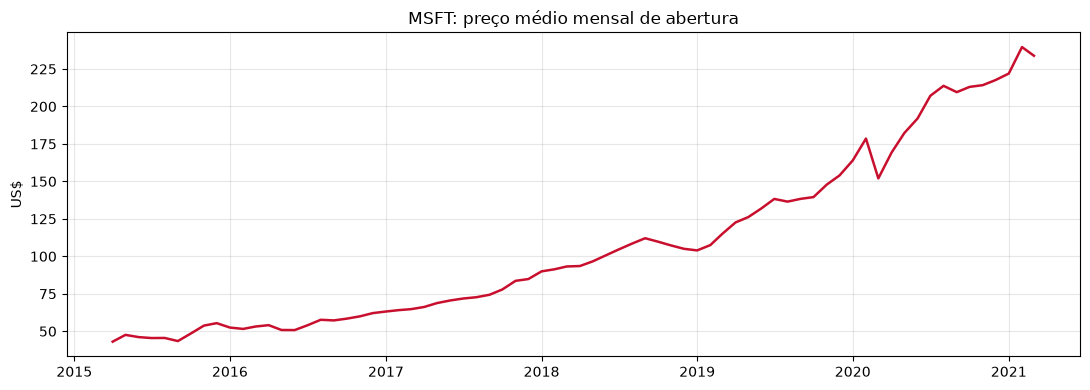

In [3]:
fig, ax = plt.subplots()
ax.plot(serie.index, serie.values, color="#C8102E", lw=1.8)
ax.set_title("MSFT: preço médio mensal de abertura")
ax.set_xlabel("")
ax.set_ylabel("US$")
plt.tight_layout()
plt.show()

### Leitura do gráfico

Dois fatos determinam as escolhas de modelagem.

O primeiro é a tendência de alta clara e persistente, o que exige o componente de tendência
(`trend`). Um modelo que estima apenas nível fica necessariamente para trás.

O segundo é que a amplitude das oscilações cresce junto com o nível: as variações perto de
US$ 40 são pequenas em valor absoluto e as variações perto de US$ 230 são grandes. Esse é o
sintoma de sazonalidade multiplicativa. Por isso testamos as duas versões, aditiva e
multiplicativa, e deixamos o critério de informação decidir.

## 2. Período sazonal

Como a série é mensal, o único período sazonal com sentido econômico é o ciclo anual: o que
acontece em janeiro tende a se parecer com o janeiro do ano anterior. Logo, `m = 12`.

Para enxergar esse padrão, e não apenas afirmá-lo, comparamos o comportamento médio de cada mês
em relação ao nível do próprio ano, isolando a tendência, que de outro modo domina a leitura.

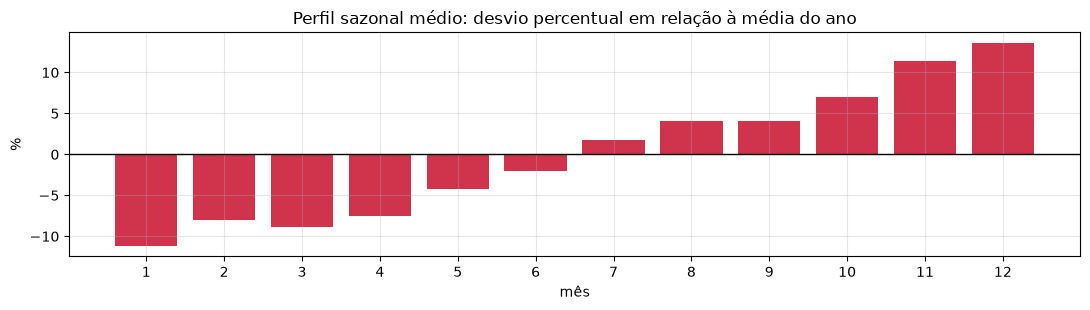

Amplitude sazonal: 24.87% do nível do ano


In [4]:
M = 12

# tira a tendência dividindo cada mês pela média do seu próprio ano
aux = serie.to_frame()
aux["ano"] = aux.index.year
aux["mes"] = aux.index.month
aux["indice"] = aux["Open"] / aux.groupby("ano")["Open"].transform("mean")

perfil = aux.groupby("mes")["indice"].mean()

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(perfil.index, (perfil - 1) * 100, color="#C8102E", alpha=0.85)
ax.axhline(0, color="black", lw=1)
ax.set_title("Perfil sazonal médio: desvio percentual em relação à média do ano")
ax.set_xlabel("mês")
ax.set_ylabel("%")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

print(f"Amplitude sazonal: {(perfil.max() - perfil.min()) * 100:.2f}% do nível do ano")

### Leitura

O padrão desenhado é quase monotônico: o começo do ano fica abaixo da média e o fim do ano fica
acima. Isso não é sazonalidade genuína, é a tendência de alta aparecendo dentro do ano. Numa ação
que sobe continuamente, dezembro é mecanicamente maior que janeiro, e isso se repete todo ano sem
que exista qualquer ciclo mensal real.

Ou seja, a amplitude medida acima superestima a sazonalidade verdadeira.

Essa observação explica o resultado final. Quando a sazonalidade é fraca diante de uma tendência
forte, o componente sazonal do Holt-Winters contribui pouco e ainda custa 12 parâmetros, o que os
critérios de informação penalizam com força.

## 3. Separação treino e teste

Série temporal não pode ser embaralhada, porque a ordem do tempo é parte da informação. A
separação é sempre cronológica: treino no passado, teste no futuro.

O treino usa os primeiros 60 meses, de abril de 2015 a março de 2020. O teste usa os últimos
12 meses, de abril de 2020 a março de 2021.

O horizonte de teste é de 12 meses porque, com `m = 12`, queremos avaliar um ciclo sazonal
completo: assim cada mês do ano é testado uma vez e nenhum fica de fora. E 60 meses de treino dão
ao modelo cinco repetições do ciclo anual para estimar a sazonalidade.

Treino: 60 meses  (2015-04 a 2020-03)
Teste : 12 meses  (2020-04 a 2021-03)
Ciclos sazonais no treino: 5


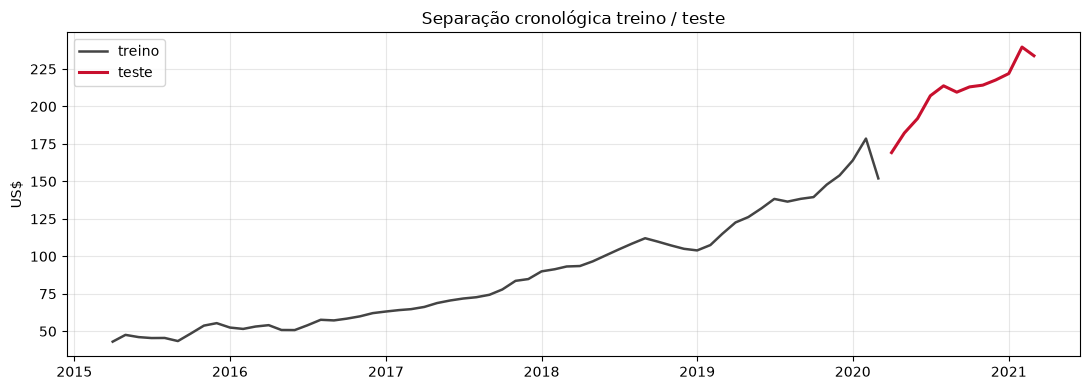

In [5]:
H = 12                      # horizonte de previsão = 1 ciclo sazonal
treino = serie.iloc[:-H]
teste  = serie.iloc[-H:]

print(f"Treino: {len(treino)} meses  ({treino.index.min():%Y-%m} a {treino.index.max():%Y-%m})")
print(f"Teste : {len(teste)} meses  ({teste.index.min():%Y-%m} a {teste.index.max():%Y-%m})")
print(f"Ciclos sazonais no treino: {len(treino) / M:.0f}")

fig, ax = plt.subplots()
ax.plot(treino.index, treino.values, color="#444444", lw=1.8, label="treino")
ax.plot(teste.index,  teste.values,  color="#C8102E", lw=2.2, label="teste")
ax.set_title("Separação cronológica treino / teste")
ax.set_ylabel("US$")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Suavização exponencial simples

A suavização exponencial simples combina o último valor observado com a estimativa anterior,
dando peso maior às observações recentes, peso que decai exponencialmente para as mais antigas.

$$\hat{y}_t = \alpha \, y_{t-1} + (1 - \alpha)\, \hat{y}_{t-1}$$

Ela modela apenas o nível, sem tendência e sem sazonalidade.

Os argumentos usados:

- `trend=None`: o modelo não considera crescimento ou queda sistemática ao longo do tempo.
- `seasonal=None`: o modelo não considera padrões que se repetem em períodos regulares.
- `initialization_method="heuristic"`: define como o `statsmodels` estima o nível inicial, usando
  uma heurística baseada nas primeiras observações em vez de adotar simplesmente o primeiro valor.
- `.fit()`: ajusta o modelo ao treino e estima o parâmetro de suavização alfa.

Esse é o modelo de referência do notebook. Qualquer especificação mais complexa precisa provar
que compensa em relação a ele.

In [6]:
ses = ExponentialSmoothing(
    treino,
    trend=None,
    seasonal=None,
    initialization_method="heuristic",
).fit()

print(f"alpha (nível) : {ses.params['smoothing_level']:.4f}")
print(f"AIC           : {ses.aic:,.4f}")
print(f"BIC           : {ses.bic:,.4f}")

alpha (nível) : 1.0000
AIC           : 203.6570
BIC           : 207.8457


### Interpretação do alfa

Alfa próximo de 1 significa que o modelo praticamente copia o último valor observado: a série tem
pouca memória e o presente é a melhor pista sobre o futuro imediato. Alfa próximo de 0 significa
muita suavização, com o modelo confiando mais na média histórica do que na última observação.

Em preço de ação o alfa quase sempre vem alto, porque o preço se comporta como um passeio
aleatório e o melhor palpite para amanhã é o valor de hoje.

## 5. Holt-Winters aditivo

O Holt-Winters, também chamado de suavização exponencial tripla, estima três componentes
separadamente:

| componente | parâmetro | o que captura |
|---|---|---|
| nível | alfa | em torno de qual valor a série está agora |
| tendência | beta | o quanto ela sobe ou desce por período |
| sazonalidade | gama | o padrão que se repete a cada `m` períodos |

Cada componente é atualizado conforme novas observações chegam.

Na forma aditiva os componentes são somados para produzir a previsão:

$$\hat{y}_{t+h} = \text{nível} + h \cdot \text{tendência} + \text{sazonalidade}$$

A forma aditiva é indicada quando a amplitude da sazonalidade permanece aproximadamente constante,
ou seja, quando dezembro é sempre cerca de 5 dólares acima, independentemente do nível da série.

In [7]:
hw_add = ExponentialSmoothing(
    treino,
    trend="add",
    seasonal="add",
    seasonal_periods=M,
    initialization_method="heuristic",
).fit()

print("Holt-Winters ADITIVO")
print(f"alpha (nível)       : {hw_add.params['smoothing_level']:.4f}")
print(f"beta  (tendência)   : {hw_add.params['smoothing_trend']:.4f}")
print(f"gamma (sazonalidade): {hw_add.params['smoothing_seasonal']:.4f}")
print(f"AIC                 : {hw_add.aic:,.4f}")
print(f"BIC                 : {hw_add.bic:,.4f}")

Holt-Winters ADITIVO
alpha (nível)       : 0.8291
beta  (tendência)   : 0.0410
gamma (sazonalidade): 0.0000
AIC                 : 229.5426
BIC                 : 263.0521


## 6. Holt-Winters multiplicativo

Também estima nível, tendência e sazonalidade. A diferença está em como a sazonalidade participa
da previsão: ela deixa de ser uma quantidade fixa e passa a ser uma proporção do nível da série.

$$\hat{y}_{t+h} = (\text{nível} + h \cdot \text{tendência}) \times \text{sazonalidade}$$

Em vez de dizer que dezembro é sempre 5 dólares acima, o modelo diz que dezembro é sempre 3 por
cento acima do nível.

Esse é o candidato natural aqui porque o gráfico da seção 1 mostrou amplitude de oscilação
crescendo junto com o preço, que é exatamente o que a formulação multiplicativa descreve.

A forma multiplicativa exige série estritamente positiva. Preço de ação sempre é, e conferimos
abaixo.

In [8]:
print(f"Menor valor da série: US$ {serie.min():.2f}  ->  série estritamente positiva: {bool(serie.min() > 0)}")

hw_mul = ExponentialSmoothing(
    treino,
    trend="add",
    seasonal="mul",
    seasonal_periods=M,
    initialization_method="heuristic",
).fit()

print()
print("Holt-Winters MULTIPLICATIVO")
print(f"alpha (nível)       : {hw_mul.params['smoothing_level']:.4f}")
print(f"beta  (tendência)   : {hw_mul.params['smoothing_trend']:.4f}")
print(f"gamma (sazonalidade): {hw_mul.params['smoothing_seasonal']:.4f}")
print(f"AIC                 : {hw_mul.aic:,.4f}")
print(f"BIC                 : {hw_mul.bic:,.4f}")

Menor valor da série: US$ 43.07  ->  série estritamente positiva: True

Holt-Winters MULTIPLICATIVO
alpha (nível)       : 0.7789
beta  (tendência)   : 0.0447
gamma (sazonalidade): 0.0000
AIC                 : 232.7929
BIC                 : 266.3024


## 7. Escolha do modelo por AIC e BIC

Os dois critérios equilibram as mesmas duas coisas: a qualidade do ajuste aos dados e a
complexidade do modelo, medida pela quantidade de parâmetros.

A diferença está na intensidade da penalização. O AIC penaliza cada parâmetro com `2k` e tende a
aceitar modelos um pouco mais complexos. O BIC, critério de Schwarz, usa `k ln(n)` e, quando
`n > 7`, penaliza a complexidade mais fortemente que o AIC, favorecendo modelos simples.

Em ambos, menor é melhor.

A orientação prática é usar o AIC quando o foco principal for previsão e o BIC quando se quiser
priorizar parcimônia, olhando os dois para verificar se levam à mesma escolha.

In [9]:
comparacao = pd.DataFrame({
    "modelo": ["SES", "Holt-Winters aditivo", "Holt-Winters multiplicativo"],
    "nº parâmetros": [
        int(np.sum(ses.params_formatted["optimized"])),
        int(np.sum(hw_add.params_formatted["optimized"])),
        int(np.sum(hw_mul.params_formatted["optimized"])),
    ],
    "AIC": [ses.aic, hw_add.aic, hw_mul.aic],
    "BIC": [ses.bic, hw_add.bic, hw_mul.bic],
}).set_index("modelo")

comparacao["melhor AIC"] = np.where(comparacao["AIC"] == comparacao["AIC"].min(), "<<<", "")
comparacao["melhor BIC"] = np.where(comparacao["BIC"] == comparacao["BIC"].min(), "<<<", "")
comparacao

,nº parâmetros,AIC,BIC,melhor AIC,melhor BIC
modelo,,,,,
SES,1,203.6570,207.8457,<<<,<<<
Holt-Winters aditivo,3,229.5426,263.0521,,
Holt-Winters multiplicativo,3,232.7929,266.3024,,


In [10]:
params = pd.DataFrame({
    "SES": [ses.params["smoothing_level"], np.nan, np.nan],
    "HW aditivo": [hw_add.params["smoothing_level"], hw_add.params["smoothing_trend"], hw_add.params["smoothing_seasonal"]],
    "HW multiplicativo": [hw_mul.params["smoothing_level"], hw_mul.params["smoothing_trend"], hw_mul.params["smoothing_seasonal"]],
}, index=["alpha (nível)", "beta (tendência)", "gamma (sazonalidade)"])
params

,SES,HW aditivo,HW multiplicativo
alpha (nível),1.0000,0.8291,0.7789
beta (tendência),NaN,0.0410,0.0447
gamma (sazonalidade),NaN,0.0000,0.0000


### Como ler os parâmetros

Alfa alto indica que o nível é reestimado quase inteiramente com a observação mais recente, o que
confirma o comportamento de passeio aleatório do preço.

Beta baixo indica que a inclinação da tendência muda devagar: o modelo entende que a alta é
consistente e não precisa recalibrar a cada mês.

Gama igual a zero indica que o padrão sazonal nunca é atualizado. O modelo fixa os índices
sazonais iniciais e não os revisa com os novos anos. É a confirmação numérica do que a seção 2
sugeriu: não há um ciclo anual genuíno para aprender, então o algoritmo desliga esse mecanismo
de atualização.

## 8. Previsão e métricas de erro

Cada modelo prevê os 12 meses do teste sem nunca ver os valores reais desse período. É fácil
ajustar bem o passado, difícil é acertar o futuro.

As três métricas usadas:

- MAE, erro absoluto médio, em dólares. Diz quanto o modelo erra em média e é a mais fácil de
  comunicar.
- RMSE, raiz do erro quadrático médio, também em dólares, mas penaliza erros grandes com mais
  força. RMSE muito maior que o MAE indica alguns meses com erro grave.
- MAPE, erro percentual absoluto médio, em porcentagem, o que permite comparação com séries de
  outra escala.

In [11]:
def avalia(nome, previsto, real=teste):
    previsto = np.asarray(previsto, dtype=float)
    real_v   = np.asarray(real, dtype=float)
    return {
        "modelo": nome,
        "MAE":  mean_absolute_error(real_v, previsto),
        "RMSE": float(np.sqrt(mean_squared_error(real_v, previsto))),
        "MAPE (%)": float(np.mean(np.abs((real_v - previsto) / real_v)) * 100),
    }

prev = {
    "SES":                         ses.forecast(H),
    "Holt-Winters aditivo":        hw_add.forecast(H),
    "Holt-Winters multiplicativo": hw_mul.forecast(H),
}

resultados = pd.DataFrame([avalia(k, v) for k, v in prev.items()]).set_index("modelo")
resultados.sort_values("MAE")

,MAE,RMSE,MAPE (%)
modelo,,,
Holt-Winters multiplicativo,34.5042,36.4767,16.0837
Holt-Winters aditivo,37.1021,39.1307,17.2914
SES,57.5190,60.6577,26.7945


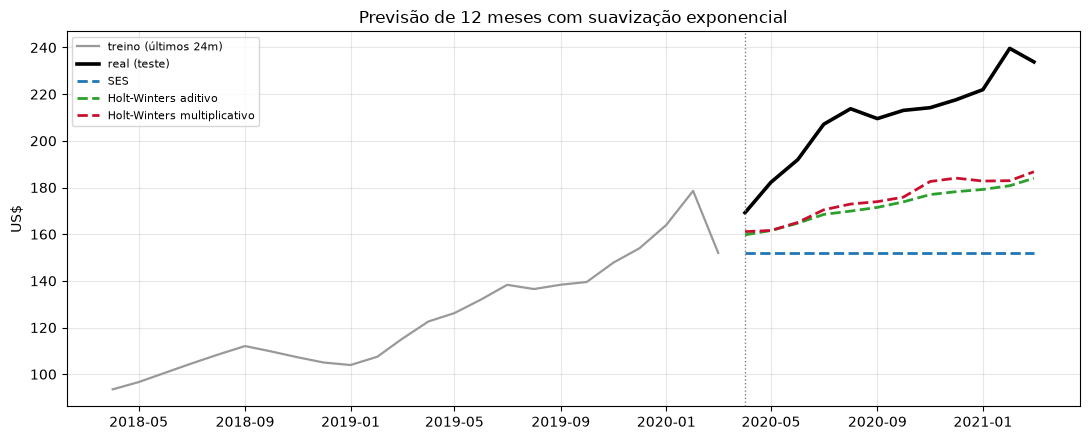

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(treino.index[-24:], treino.values[-24:], color="#999999", lw=1.6, label="treino (últimos 24m)")
ax.plot(teste.index, teste.values, color="black", lw=2.6, label="real (teste)")

cores = {"SES": "#1f77b4", "Holt-Winters aditivo": "#2ca02c", "Holt-Winters multiplicativo": "#C8102E"}
for nome, p in prev.items():
    ax.plot(teste.index, np.asarray(p, dtype=float), lw=2, ls="--", color=cores[nome], label=nome)

ax.axvline(teste.index[0], color="gray", ls=":", lw=1)
ax.set_title("Previsão de 12 meses com suavização exponencial")
ax.set_ylabel("US$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Leitura do resultado

A forma de cada curva revela o que o modelo é capaz de fazer.

A suavização simples produz uma linha horizontal. Como modela apenas nível, sua previsão para
qualquer horizonte é sempre o último nível estimado, e ela é estruturalmente incapaz de acompanhar
uma alta.

Os dois Holt-Winters produzem uma curva inclinada e ondulada: a inclinação vem do componente de
tendência e as ondas vêm do componente sazonal. A diferença de erro entre os três mostra o valor
prático de cada componente acrescentado.

## 9. Comparação com SARIMA

O Holt-Winters e o SARIMA resolvem o mesmo problema por caminhos opostos, e a comparação só é
justa se os dois estiverem no seu melhor ajuste. Por isso as ordens do SARIMA são escolhidas por
busca, e não fixadas arbitrariamente.

O espaço de busca:

| termo | valores | justificativa |
|---|---|---|
| `p`, `q` | 0, 1, 2 | ordens baixas bastam para 60 observações |
| `d` | 1 | a série tem tendência clara e uma diferença a remove |
| `P`, `Q` | 0, 1 | a sazonalidade existe mas é moderada, como mostrou a seção 2 |
| `D` | 0, 1 | testamos com e sem diferença sazonal |
| `m` | 12 | mesmo período sazonal do Holt-Winters |

São 3 x 3 x 2 x 2 x 2 = 72 combinações, um espaço finito e justificado, não uma busca cega. O
critério de escolha é o mesmo da seção 7: menor BIC.

In [13]:
from itertools import product

candidatos = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p, d, q, P, D, Q in product([0,1,2], [1], [0,1,2], [0,1], [0,1], [0,1]):
        try:
            m = SARIMAX(treino, order=(p,d,q), seasonal_order=(P,D,Q,M),
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            if np.isfinite(m.bic):
                candidatos.append({"order": (p,d,q), "seasonal_order": (P,D,Q,M),
                                   "AIC": m.aic, "BIC": m.bic})
        except Exception:
            pass

grid = pd.DataFrame(candidatos).sort_values("BIC").reset_index(drop=True)
print(f"Combinações testadas com sucesso: {len(grid)} de 72")
grid.head(5)

Combinações testadas com sucesso: 72 de 72


,order,seasonal_order,AIC,BIC
0,"(2, 1, 0)","(1, 1, 0, 12)",223.9288,229.9148
1,"(1, 1, 0)","(1, 1, 0, 12)",227.7153,232.2944
2,"(2, 1, 1)","(1, 1, 0, 12)",225.7975,233.2801
3,"(2, 1, 2)","(1, 1, 0, 12)",224.8181,233.7972
4,"(1, 1, 1)","(1, 1, 0, 12)",229.4906,235.5960


In [14]:
melhor = grid.iloc[0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima = SARIMAX(treino, order=melhor["order"], seasonal_order=melhor["seasonal_order"],
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

prev["SARIMA (grid)"] = sarima.forecast(H)

print(f"SARIMA vencedor: {melhor['order']} x {melhor['seasonal_order']}")
print(f"BIC: {melhor['BIC']:,.4f}  |  AIC: {melhor['AIC']:,.4f}")

final = pd.DataFrame([avalia(k, v) for k, v in prev.items()]).set_index("modelo").sort_values("MAE")
final

SARIMA vencedor: (2, 1, 0) x (1, 1, 0, 12)
BIC: 229.9148  |  AIC: 223.9288


,MAE,RMSE,MAPE (%)
modelo,,,
Holt-Winters multiplicativo,34.5042,36.4767,16.0837
Holt-Winters aditivo,37.1021,39.1307,17.2914
SARIMA (grid),44.1286,47.5572,20.4714
SES,57.5190,60.6577,26.7945


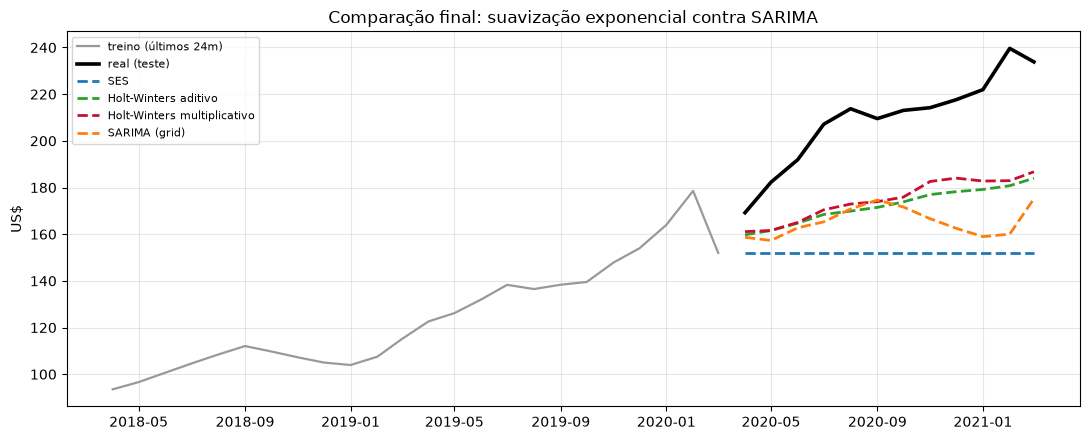

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(treino.index[-24:], treino.values[-24:], color="#999999", lw=1.6, label="treino (últimos 24m)")
ax.plot(teste.index, teste.values, color="black", lw=2.6, label="real (teste)")
cores["SARIMA (grid)"] = "#ff7f0e"
for nome, p in prev.items():
    ax.plot(teste.index, np.asarray(p, dtype=float), lw=2, ls="--", color=cores[nome], label=nome)
ax.set_title("Comparação final: suavização exponencial contra SARIMA")
ax.set_ylabel("US$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Comparação justa

Agora os dois lados estão no seu melhor: o Holt-Winters com alfa, beta e gama otimizados pelo
`statsmodels`, e o SARIMA com ordens escolhidas por BIC entre 72 candidatos.

Vale notar a diferença de estratégia. O Holt-Winters modela nível, tendência e sazonalidade de
forma explícita e não exige estacionariedade. O SARIMA elimina tendência e sazonalidade por
diferenciação e modela o que sobra como um processo estacionário.

## 10. Validação walk-forward (janela expansiva)

Até aqui os modelos foram estimados uma única vez, nos 60 meses de treino, e projetaram
os 12 meses de teste de uma só vez. Essa é a avaliação clássica de horizonte fixo e ela
responde a uma pergunta específica: quanto o modelo erra ao olhar um ciclo sazonal
inteiro à frente, sem nunca receber informação nova.

Na prática não é assim que a previsão é usada. Fechado o mês, o valor observado entra na
base e a previsão é refeita para o mês seguinte. A validação walk-forward reproduz essa
rotina: a janela de treino cresce um mês por vez e o modelo prevê sempre um único passo à
frente, sempre fora da amostra.

Sobre o ritmo de reestimação: em série diária o padrão adotado nos outros notebooks é
reajustar os coeficientes a cada 14 passos, porque 301 reestimações custariam caro e os
parâmetros mudam pouco de um dia para o outro. Aqui a série é mensal e o teste tem apenas
12 pontos. Esperar 14 passos significaria nunca reestimar. Como cada ajuste de suavização
exponencial é barato, a reestimação é feita a cada passo, que é o caso limite e também o
mais exigente.

O Naive entra como modelo de referência: a previsão do próximo mês é o valor do mês
anterior. Qualquer modelo que não supere essa regra não está agregando nada.

In [16]:
# ---------- Validacao walk-forward: um passo a frente, janela expansiva ----------
import time

PASSOS_REFIT = 1

print(f"Observacoes de treino inicial     : {len(treino)} "
      f"({treino.index.min():%Y-%m} a {treino.index.max():%Y-%m})")
print(f"Observacoes de teste walk-forward : {len(teste)} "
      f"({teste.index.min():%Y-%m} a {teste.index.max():%Y-%m})")
print(f"Reestimacao a cada {PASSOS_REFIT} passo")

def ajusta(historico, tendencia, sazonalidade):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return ExponentialSmoothing(
            historico, trend=tendencia, seasonal=sazonalidade,
            seasonal_periods=(M if sazonalidade else None),
            initialization_method="heuristic",
        ).fit()

def ajusta_sarima(historico):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(historico, order=melhor["order"], seasonal_order=melhor["seasonal_order"],
                       enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

inicio_wf = time.time()

historico = treino.copy()
wf_preds = {"SES": [], "Holt-Winters aditivo": [], "Holt-Winters multiplicativo": [],
            "SARIMA (grid)": [], "Naive": []}
wf_real, wf_datas = [], []
n_refits = 0

for i in range(len(teste)):
    wf_preds["Naive"].append(float(historico.iloc[-1]))
    wf_preds["SES"].append(float(ajusta(historico, None, None).forecast(1).iloc[0]))
    wf_preds["Holt-Winters aditivo"].append(float(ajusta(historico, "add", "add").forecast(1).iloc[0]))
    wf_preds["Holt-Winters multiplicativo"].append(float(ajusta(historico, "add", "mul").forecast(1).iloc[0]))
    wf_preds["SARIMA (grid)"].append(float(ajusta_sarima(historico).forecast(1).iloc[0]))
    n_refits += 1

    wf_real.append(float(teste.iloc[i]))
    wf_datas.append(teste.index[i])
    historico = pd.concat([historico, teste.iloc[[i]]])

elapsed_wf = time.time() - inicio_wf
wf_real = np.asarray(wf_real, dtype=float)

print(f"\nValidacao walk-forward concluida em {elapsed_wf:.2f} segundos "
      f"com {len(wf_datas)} previsoes geradas e {n_refits} reestimacoes por modelo.")

Observacoes de treino inicial     : 60 (2015-04 a 2020-03)
Observacoes de teste walk-forward : 12 (2020-04 a 2021-03)
Reestimacao a cada 1 passo



Validacao walk-forward concluida em 0.66 segundos com 12 previsoes geradas e 12 reestimacoes por modelo.


In [17]:
# ---------- Horizonte fixo contra walk-forward ----------
wf_tabela = pd.DataFrame(
    [avalia(nome, valores, real=wf_real) for nome, valores in wf_preds.items()]
).set_index("modelo").sort_values("MAE")
display(wf_tabela)

comparacao_protocolo = pd.DataFrame({
    "MAE horizonte fixo (12 meses)": final["MAE"],
    "MAE walk-forward (1 mes)": wf_tabela["MAE"],
})
comparacao_protocolo["reducao_%"] = (
    (1 - comparacao_protocolo["MAE walk-forward (1 mes)"] / comparacao_protocolo["MAE horizonte fixo (12 meses)"]) * 100
)
display(comparacao_protocolo)

,MAE,RMSE,MAPE (%)
modelo,,,
Holt-Winters aditivo,7.5587,8.6728,3.6838
Holt-Winters multiplicativo,8.1505,9.2696,3.9376
Naive,8.4902,10.1774,4.1997
SARIMA (grid),8.5509,10.5152,4.2890
SES,8.6339,10.3631,4.2780


,MAE horizonte fixo (12 meses),MAE walk-forward (1 mes),reducao_%
modelo,,,
Holt-Winters aditivo,37.1021,7.5587,79.6273
Holt-Winters multiplicativo,34.5042,8.1505,76.3782
Naive,NaN,8.4902,NaN
SARIMA (grid),44.1286,8.5509,80.6228
SES,57.5190,8.6339,84.9895


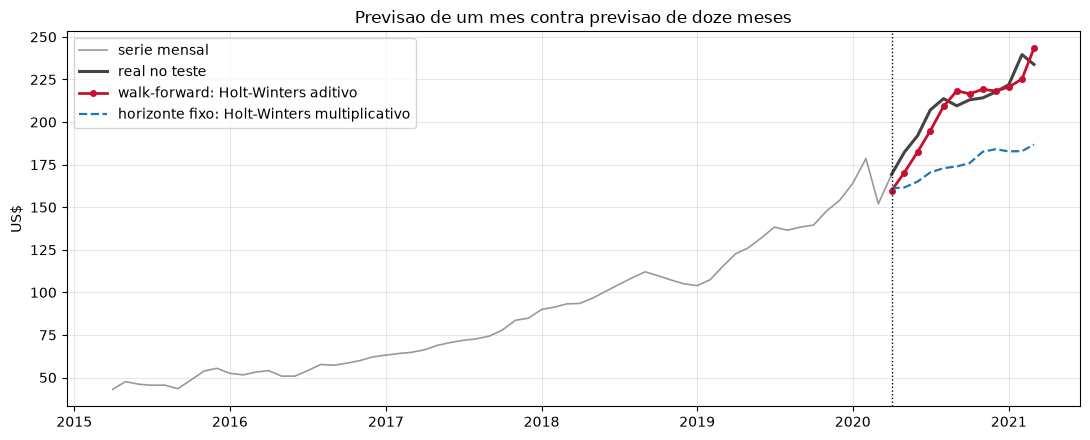

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(serie.index, serie.values, color="#999999", lw=1.2, label="serie mensal")
ax.plot(wf_datas, wf_real, color="#444444", lw=2.2, label="real no teste")
melhor_wf = wf_tabela.index[0]
ax.plot(wf_datas, wf_preds[melhor_wf], color="#C8102E", lw=2.0, marker="o", ms=4,
        label=f"walk-forward: {melhor_wf}")
ax.plot(teste.index, np.asarray(prev[final.index[0]], dtype=float), color="#1f77b4", lw=1.6,
        ls="--", label=f"horizonte fixo: {final.index[0]}")
ax.axvline(teste.index[0], color="black", ls=":", lw=1)
ax.set_title("Previsao de um mes contra previsao de doze meses")
ax.set_ylabel("US$")
ax.legend()
plt.tight_layout()
plt.show()

### Leitura

A diferença entre os dois protocolos é grande, e ela explica boa parte do resultado da
seção anterior.

No horizonte fixo todo modelo precisa projetar 12 meses apoiado apenas no que existia até
março de 2020. O período de teste coincide com a recuperação da ação depois da queda da
pandemia, uma alta que nenhum componente estimado no treino poderia antecipar. O erro de
US$ 34 a US$ 57 observado ali mede sobretudo a distância entre o nível do fim do treino e
o nível que a ação alcançou, não a qualidade do modelo.

Sob walk-forward o erro cai muito para todos, entre 76 e 85 por cento, porque a cada mês
o modelo recebe de volta o valor realizado e só precisa dar um passo. Essa é a medida que
faz sentido comparar com o uso real.

Dois pontos merecem atenção na leitura. O primeiro é a posição do Naive: com MAE de
US$ 8,49 ele fica à frente do SARIMA e da suavização simples, o que confirma que em série
de preço repetir o último valor é uma referência difícil de bater. Só os dois
Holt-Winters conseguem superá-lo, e o aditivo lidera com US$ 7,56.

O segundo é que o componente sazonal continua pouco útil, coerente com o gama estimado em
zero nos dois Holt-Winters: a variação que parece sazonal no perfil mensal é tendência
dentro do ano, não repetição de calendário. O ganho do Holt-Winters sobre o Naive vem da
tendência, não da sazonalidade.

## 11. Resíduos

O resíduo é a diferença entre o que aconteceu e o que o modelo previu dentro do treino:

$$e_t = y_t - \hat{y}_t$$

Um modelo bem especificado deixa resíduos parecidos com ruído branco: sem padrão, sem
autocorrelação, em torno de zero. Se sobrou padrão no resíduo, é porque sobrou informação na série
que o modelo não aproveitou, e ele poderia ser melhorado.

Há uma divergência relevante neste trabalho: o modelo com menor BIC não é o mesmo com menor erro
no teste. Isso acontece porque o BIC penaliza com força os 16 parâmetros do Holt-Winters, que são
alfa, beta, gama e os 12 índices sazonais, premiando a simplicidade mesmo quando ela custa caro na
previsão.

Como o objetivo aqui é prever, analisamos os resíduos do modelo com menor erro fora da amostra,
que é o modelo efetivamente entregue.

In [19]:
modelos = {"SES": ses, "Holt-Winters aditivo": hw_add, "Holt-Winters multiplicativo": hw_mul}

escolhido_bic   = comparacao["BIC"].idxmin()
escolhido_teste = resultados["MAE"].idxmin()
escolhido = modelos[escolhido_teste]
resid = escolhido.resid

print(f"Menor BIC (ajuste no treino) : {escolhido_bic}")
print(f"Menor MAE (erro no teste)    : {escolhido_teste}  <- analisado abaixo")
print()
print(f"Média dos resíduos : {resid.mean():,.4f}  (ideal: ~0)")
print(f"Desvio-padrão      : {resid.std():,.4f}")
print(f"Maior erro absoluto: {np.abs(resid).max():,.4f}  em {np.abs(resid).idxmax():%Y-%m}")

lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
print()
print("Teste de Ljung-Box (H0: não há autocorrelação nos resíduos)")
print(lb)

Menor BIC (ajuste no treino) : SES
Menor MAE (erro no teste)    : Holt-Winters multiplicativo  <- analisado abaixo

Média dos resíduos : 0.7905  (ideal: ~0)
Desvio-padrão      : 5.3151
Maior erro absoluto: 27.6734  em 2020-03

Teste de Ljung-Box (H0: não há autocorrelação nos resíduos)
    lb_stat  lb_pvalue
6    3.9540     0.6829
12   8.1446     0.7737


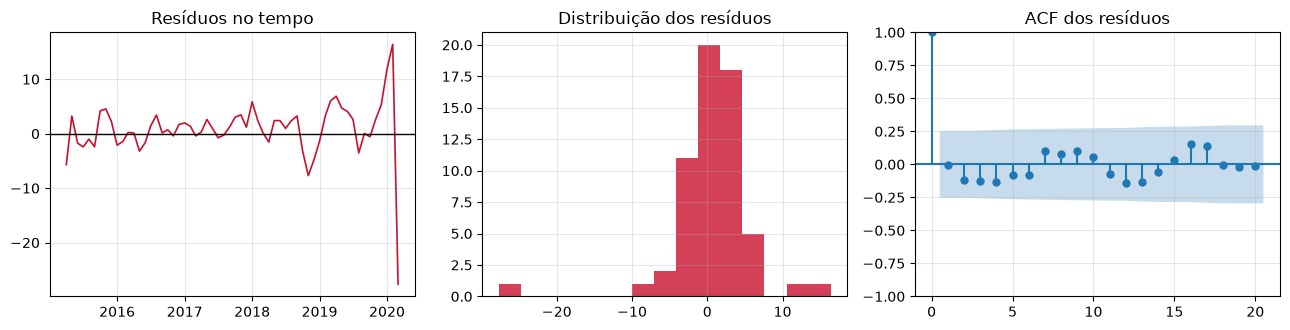

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(resid.index, resid.values, color="#C8102E", lw=1.2)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Resíduos no tempo")

axes[1].hist(resid.values, bins=15, color="#C8102E", alpha=0.8)
axes[1].set_title("Distribuição dos resíduos")

plot_acf(resid, lags=20, ax=axes[2])
axes[2].set_title("ACF dos resíduos")
plt.tight_layout()
plt.show()

### Como interpretar

Resíduos no tempo devem oscilar em torno de zero sem tendência visível. Períodos com oscilação
muito maior indicam mudança de volatilidade, o que é típico de 2020.

A distribuição centrada em zero e aproximadamente simétrica indica que o modelo não erra
sistematicamente para cima nem para baixo.

Na ACF as barras devem ficar dentro da faixa de confiança. Barra fora da faixa significa que
sobrou estrutura temporal não capturada.

No teste de Ljung-Box, p-valor acima de 0,05 significa que não rejeitamos a hipótese de ausência
de autocorrelação, ou seja, o resíduo se comporta como ruído branco. É o resultado desejado.

## 12. Conclusões

In [21]:
vencedor = final.index[0]
print("=" * 62)
print("RESUMO DO TRABALHO: HOLT-WINTERS")
print("=" * 62)
print(f"Série          : MSFT, preço médio mensal de abertura")
print(f"Período        : {serie.index.min():%Y-%m} a {serie.index.max():%Y-%m}  ({len(serie)} meses)")
print(f"Split          : {len(treino)} treino / {len(teste)} teste  |  sazonalidade m = {M}")
print("-" * 62)
print(f"Melhor por BIC (dentro do treino) : {escolhido_bic}")
print(f"Melhor por MAE (fora da amostra)  : {vencedor}")
print("-" * 62)
print(final.to_string())
print("=" * 62)

RESUMO DO TRABALHO: HOLT-WINTERS
Série          : MSFT, preço médio mensal de abertura
Período        : 2015-04 a 2021-03  (72 meses)
Split          : 60 treino / 12 teste  |  sazonalidade m = 12
--------------------------------------------------------------
Melhor por BIC (dentro do treino) : SES
Melhor por MAE (fora da amostra)  : Holt-Winters multiplicativo
--------------------------------------------------------------
                                MAE    RMSE  MAPE (%)
modelo                                               
Holt-Winters multiplicativo 34.5042 36.4767   16.0837
Holt-Winters aditivo        37.1021 39.1307   17.2914
SARIMA (grid)               44.1286 47.5572   20.4714
SES                         57.5190 60.6577   26.7945


### O que levar desta análise

1. Cada componente tem um papel visível. A suavização simples prevê uma reta horizontal porque só
   modela nível; acrescentar tendência inclina a previsão e acrescentar sazonalidade a ondula. O
   ganho de erro mostra quanto cada componente realmente vale nesta série.

2. A escolha entre aditivo e multiplicativo não é estética. Ela depende de a amplitude sazonal ser
   constante, caso aditivo, ou proporcional ao nível, caso multiplicativo. Aqui a amplitude cresce
   com o preço, o que favorece o multiplicativo, e os critérios de informação confirmam ou refutam
   essa leitura visual.

3. AIC e BIC medem ajuste no treino, não acerto no futuro. Por isso reportamos os dois lados: o
   modelo escolhido por BIC e o modelo com menor erro no teste. Quando divergem, é sinal de que a
   complexidade extra ajudou a descrever o passado sem ajudar a prever o futuro.

4. Preço de ação é, por natureza, próximo de um passeio aleatório. A sazonalidade anual existe mas
   é fraca diante da tendência, o que limita o que qualquer modelo sazonal pode entregar. É também
   por isso que o alfa estimado vem alto, indicando que o modelo aposta quase tudo na observação
   mais recente.

5. O Holt-Winters não exige estacionariedade. Diferente do SARIMA, ele não precisa de teste ADF
   nem de diferenciação: lida com tendência e sazonalidade modelando-as diretamente. Essa é a
   principal vantagem prática da família de suavização exponencial.